# Sensitivity Analysis: Review + Pre-Application Levels

This notebook runs the permit simulation under:
- 3 levels (e.g., 50%, 100%, 200%) for review stages
  - Planning
  - Public works
  - Fire
  - Special zoning
  - Agency referral
- multiple pre-application distribution options
  - baseline
  - lognormal_180
  - lognormal_60
  - poisson_10
  - lognormal_10

Levels scale review durations, and planning/public works staffing can also be set
from baseline staff values (`PLANNING_STAFF_BASELINE`, `PUBLIC_WORKS_STAFF_BASELINE`).

It evaluates every selected combination and summarizes outcomes (e.g., mean total days, waiting/service, county vs applicant days).

In [19]:
import itertools
import json
import time
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from run_simulation import run_simulation
from visualize_permits import calculate_step_waiting_service_totals

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [20]:
def run_duration_level_sensitivity(
    n_runs: int,
    num_permits: int,
    levels: list[float],
    pre_app_distributions: list[str],
    sequential: str = "standard",
    base_seed: int = 42,
    planning_staff_baseline: int = 20,
    public_works_staff_baseline: int = 30,
    fire_staff_baseline: int = 10,
    planning_caseload_per_staff: float = 7,
    public_works_caseload_per_staff: float = 7,
    fire_caseload_per_staff: float = 7,
):
    rows = []

    stages = [
        "planning",
        "public_works",
        "fire",
        "special_zoning",
        "agency_referral",
    ]
    step_names = [
        "EPA Debris",
        "USACE Debris",
        "Pre-Application Activities",
        "Applicant Revisions",
        "Planning",
        "Agency Referral",
        "Special Zoning",
        "Public Works",
        "Fire Review",
    ]
    level_combos = list(itertools.product(levels, repeat=len(stages)))

    total_runs = len(pre_app_distributions) * len(level_combos) * n_runs
    completed_runs = 0
    start_time = time.time()

    for pre_app_dist in pre_app_distributions:
        for combo_vals in level_combos:
            multiplier_map = dict(zip(stages, combo_vals))
            planning_staff_count = max(1, int(round(planning_staff_baseline)))
            public_works_staff_count = max(1, int(round(public_works_staff_baseline)))
            fire_staff_count = max(1, int(round(fire_staff_baseline)))

            combo_name = (
                f"pre_app={pre_app_dist} | "
                + " | ".join(f"{k}={v:.1f}x" for k, v in multiplier_map.items())
            )
            combo_name += (
                f" | planning_staff={planning_staff_count}"
                f" | public_works_staff={public_works_staff_count}"
                f" | fire_staff={fire_staff_count}"
            )

            for run_idx in range(n_runs):
                seed = base_seed + run_idx
                sim = run_simulation(
                    num_permits=num_permits,
                    random_seed=seed,
                    sequential=sequential,
                    review_duration_multipliers=multiplier_map,
                    pre_application_distribution=pre_app_dist,
                    planning_staff_count=planning_staff_count,
                    public_works_staff_count=public_works_staff_count,
                    planning_caseload_per_staff=planning_caseload_per_staff,
                    public_works_caseload_per_staff=public_works_caseload_per_staff,
                    fire_staff_count=fire_staff_count,
                    fire_caseload_per_staff=fire_caseload_per_staff,
                )
                stats = sim.get_statistics()
                completed_runs += 1
                if completed_runs % 1000 == 0 or completed_runs == total_runs:
                    elapsed = time.time() - start_time
                    avg_per_run = elapsed / completed_runs if completed_runs else 0.0
                    remaining = max(total_runs - completed_runs, 0)
                    eta_sec = remaining * avg_per_run
                    print(
                        f"Progress: {completed_runs}/{total_runs} runs "
                        f"({100.0 * completed_runs / total_runs:.1f}%) | "
                        f"elapsed {elapsed / 60:.1f} min | ETA {eta_sec / 60:.1f} min"
                    )

                if "message" in stats:
                    continue

                avg_total = stats.get("average_total_time") or {}
                total_wait = stats.get("total_waiting_time") or {}
                total_service = stats.get("total_service_time") or {}
                county_vs_app = stats.get("county_review_vs_applicant") or {}

                # Mean waiting/service time per permit for each step
                permits = sim.completed_permits
                n_permits = len(permits)

                # Planning-to-ready metric: from planning start to ready for construction
                planning_to_ready_days = [
                    (p.ready_for_construction - p.planning_request)
                    for p in permits
                    if p.planning_request is not None and p.ready_for_construction is not None
                ]
                mean_planning_to_ready_days = (
                    float(np.mean(planning_to_ready_days))
                    if planning_to_ready_days
                    else np.nan
                )

                # Debris gating metric: if debris ends after ready_for_construction,
                # permit would wait this additional time before construction can truly start.
                debris_blocking_wait_days = [
                    (p.debris_removal_end - p.ready_for_construction)
                    for p in permits
                    if p.debris_removal_end is not None
                    and p.ready_for_construction is not None
                    and p.debris_removal_end > p.ready_for_construction
                ]
                debris_blocking_wait_count = len(debris_blocking_wait_days)
                debris_blocking_wait_mean = (
                    float(np.mean(debris_blocking_wait_days))
                    if debris_blocking_wait_days
                    else 0.0
                )
                debris_blocking_wait_median = (
                    float(np.median(debris_blocking_wait_days))
                    if debris_blocking_wait_days
                    else 0.0
                )
                debris_blocking_wait_max = (
                    float(np.max(debris_blocking_wait_days))
                    if debris_blocking_wait_days
                    else 0.0
                )

                wait_sums = {s: 0.0 for s in step_names}
                service_sums = {s: 0.0 for s in step_names}
                for p in permits:
                    step_data = calculate_step_waiting_service_totals(p)
                    for s in step_names:
                        vals = step_data.get(s, {"waiting": 0.0, "service": 0.0})
                        wait_sums[s] += vals.get("waiting", 0.0)
                        service_sums[s] += vals.get("service", 0.0)

                step_cols = {}
                for s in step_names:
                    col_key = s.lower().replace(" ", "_").replace("-", "_")
                    denom = n_permits if n_permits > 0 else 1
                    step_cols[f"step_wait_mean__{col_key}"] = wait_sums[s] / denom
                    step_cols[f"step_service_mean__{col_key}"] = service_sums[s] / denom

                rows.append(
                    {
                        "combo": combo_name,
                        "pre_application_distribution": pre_app_dist,
                        "planning_staff_count": planning_staff_count,
                        "public_works_staff_count": public_works_staff_count,
                        "fire_staff_count": fire_staff_count,
                        "planning_level": multiplier_map["planning"],
                        "public_works_level": multiplier_map["public_works"],
                        "fire_level": multiplier_map["fire"],
                        "special_zoning_level": multiplier_map["special_zoning"],
                        "agency_referral_level": multiplier_map["agency_referral"],
                        "run": run_idx,
                        "seed": seed,
                        "completed_permits": n_permits,
                        "mean_total_days": avg_total.get("mean", np.nan),
                        "mean_application_to_ready_days": mean_planning_to_ready_days,
                        "planning_to_ready_n": len(planning_to_ready_days),
                        "debris_blocking_wait_count": debris_blocking_wait_count,
                        "debris_blocking_wait_share": (
                            debris_blocking_wait_count / n_permits if n_permits > 0 else np.nan
                        ),
                        "debris_blocking_wait_mean_days": debris_blocking_wait_mean,
                        "debris_blocking_wait_median_days": debris_blocking_wait_median,
                        "debris_blocking_wait_max_days": debris_blocking_wait_max,
                        "median_total_days": avg_total.get("median", np.nan),
                        "std_total_days": avg_total.get("std", np.nan),
                        "min_total_days": avg_total.get("min", np.nan),
                        "max_total_days": avg_total.get("max", np.nan),
                        "mean_wait_days": total_wait.get("mean", np.nan),
                        "mean_service_days": total_service.get("mean", np.nan),
                        "county_review_mean": county_vs_app.get("county_review_mean", np.nan),
                        "applicant_mean": county_vs_app.get("applicant_mean", np.nan),
                        "debris_mean": county_vs_app.get("debris_mean", np.nan),
                        "stats_json": json.dumps(stats),
                        **step_cols,
                    }
                )

    return pd.DataFrame(rows)

In [21]:
# --- Experiment settings ---
levels = [0.5, 1.0, 2.0]  # 50%, 100%, 150%
pre_app_distributions = ["lognormal_180", "lognormal_60", "lognormal_10"]
# Add "baseline" to the list above if you want to include the original model behavior.

N_RUNS = 10
N_PERMITS = 1200
SEQUENTIAL_MODE = "standard"  # "standard", "parallel", or "sequential"

# Staff counts stay fixed at these baseline values across all scenarios.
PLANNING_STAFF_BASELINE = 8
PUBLIC_WORKS_STAFF_BASELINE = 12
FIRE_STAFF_BASELINE = 4
PLANNING_CASELOAD_PER_STAFF = 7
PUBLIC_WORKS_CASELOAD_PER_STAFF = 7
FIRE_CASELOAD_PER_STAFF = 7

results_df = run_duration_level_sensitivity(
    n_runs=N_RUNS,
    num_permits=N_PERMITS,
    levels=levels,
    pre_app_distributions=pre_app_distributions,
    sequential=SEQUENTIAL_MODE,
    base_seed=42,
    planning_staff_baseline=PLANNING_STAFF_BASELINE,
    public_works_staff_baseline=PUBLIC_WORKS_STAFF_BASELINE,
    fire_staff_baseline=FIRE_STAFF_BASELINE,
    planning_caseload_per_staff=PLANNING_CASELOAD_PER_STAFF,
    public_works_caseload_per_staff=PUBLIC_WORKS_CASELOAD_PER_STAFF,
    fire_caseload_per_staff=FIRE_CASELOAD_PER_STAFF,
)

print(f"Rows: {len(results_df)}")
print(f"Unique combinations: {results_df['combo'].nunique()}")
print(f"Expected combinations: {len(pre_app_distributions) * (len(levels) ** 5)}")
results_df.head()

Progress: 1000/7290 runs (13.7%) | elapsed 5.0 min | ETA 31.2 min
Progress: 2000/7290 runs (27.4%) | elapsed 9.7 min | ETA 25.7 min
Progress: 3000/7290 runs (41.2%) | elapsed 13.8 min | ETA 19.7 min
Progress: 4000/7290 runs (54.9%) | elapsed 18.6 min | ETA 15.3 min
Progress: 5000/7290 runs (68.6%) | elapsed 23.6 min | ETA 10.8 min
Progress: 6000/7290 runs (82.3%) | elapsed 28.5 min | ETA 6.1 min
Progress: 7000/7290 runs (96.0%) | elapsed 33.7 min | ETA 1.4 min
Progress: 7290/7290 runs (100.0%) | elapsed 35.2 min | ETA 0.0 min
Rows: 7290
Unique combinations: 729
Expected combinations: 729


,combo,pre_application_distribution,planning_staff_count,public_works_staff_count,fire_staff_count,planning_level,public_works_level,fire_level,special_zoning_level,agency_referral_level,run,seed,completed_permits,mean_total_days,mean_application_to_ready_days,planning_to_ready_n,debris_blocking_wait_count,debris_blocking_wait_share,debris_blocking_wait_mean_days,debris_blocking_wait_median_days,debris_blocking_wait_max_days,median_total_days,std_total_days,min_total_days,max_total_days,mean_wait_days,mean_service_days,county_review_mean,applicant_mean,debris_mean,stats_json,step_wait_mean__epa_debris,step_service_mean__epa_debris,step_wait_mean__usace_debris,step_service_mean__usace_debris,step_wait_mean__pre_application_activities,step_service_mean__pre_application_activities,step_wait_mean__applicant_revisions,step_service_mean__applicant_revisions,step_wait_mean__planning,step_service_mean__planning,step_wait_mean__agency_referral,step_service_mean__agency_referral,step_wait_mean__special_zoning,step_service_mean__special_zoning,step_wait_mean__public_works,step_service_mean__public_works,step_wait_mean__fire_review,step_service_mean__fire_review
0,pre_app=lognormal_180 | planning=0.5x | public...,lognormal_180,8,12,4,0.5,0.5,0.5,0.5,0.5,0,42,1200,321.007990,110.012841,1200,0,0.0,0.0,0.0,0.0,295.015039,129.361684,92.681338,1477.944277,11.275722,329.197973,19.417135,306.272740,14.783822,"{""total_completed"": 1200, ""total_in_progress"":...",3.235752,1.016461,8.039942,2.491667,0.0,210.995150,0.0,95.277590,0.0,3.400910,0.0,3.667349,0.0,5.981538,0.0,4.119075,0.000029,2.248235
1,pre_app=lognormal_180 | planning=0.5x | public...,lognormal_180,8,12,4,0.5,0.5,0.5,0.5,0.5,1,43,1200,316.794831,108.858296,1200,0,0.0,0.0,0.0,0.0,293.428869,123.238799,59.341571,991.459002,11.445985,324.959830,18.061478,303.373858,14.970479,"{""total_completed"": 1200, ""total_in_progress"":...",3.214872,1.010328,8.231113,2.514167,0.0,207.936534,0.0,95.437324,0.0,3.368422,0.0,3.430547,0.0,4.795789,0.0,4.162022,0.000000,2.304699
2,pre_app=lognormal_180 | planning=0.5x | public...,lognormal_180,8,12,4,0.5,0.5,0.5,0.5,0.5,2,44,1200,313.503805,107.146280,1200,0,0.0,0.0,0.0,0.0,288.852225,124.810267,97.595404,1037.822168,11.247791,321.964143,18.762795,299.724728,14.724411,"{""total_completed"": 1200, ""total_in_progress"":...",3.137635,1.000832,8.110111,2.475833,0.0,206.357525,0.0,93.367202,0.0,3.368373,0.0,3.624528,0.0,5.242240,0.0,4.118714,0.000045,2.408895
3,pre_app=lognormal_180 | planning=0.5x | public...,lognormal_180,8,12,4,0.5,0.5,0.5,0.5,0.5,3,45,1200,314.802293,110.148099,1200,0,0.0,0.0,0.0,0.0,288.153146,124.858727,98.048731,1003.466231,11.283671,323.705675,19.757984,300.433378,14.797985,"{""total_completed"": 1200, ""total_in_progress"":...",3.147904,1.007022,8.135558,2.507500,0.0,204.654194,0.0,95.779184,0.0,3.420450,0.0,4.211019,0.0,5.597085,0.0,4.124499,0.000209,2.404721
4,pre_app=lognormal_180 | planning=0.5x | public...,lognormal_180,8,12,4,0.5,0.5,0.5,0.5,0.5,4,46,1200,315.494826,109.154697,1200,0,0.0,0.0,0.0,0.0,290.072866,128.664265,77.377906,1799.474812,11.265441,323.875573,19.408617,300.963669,14.768728,"{""total_completed"": 1200, ""total_in_progress"":...",3.226570,1.017454,8.038871,2.485833,0.0,206.340129,0.0,94.623540,0.0,3.397930,0.0,3.898131,0.0,5.676970,0.0,4.125783,0.000000,2.309803


In [22]:
summary = (
    results_df
    .groupby([
        "pre_application_distribution",
        "planning_level",
        "public_works_level",
        "fire_level",
        "special_zoning_level",
        "agency_referral_level",
    ], as_index=False)
    .mean(numeric_only=True)
    .sort_values("mean_total_days")
    .reset_index(drop=True)
)

summary = summary.rename(columns={"run": "n_runs_proxy"})

print("Top 10 fastest combinations (by mean total days):")
display(summary.head(10))

print("Top 10 slowest combinations:")
display(summary.tail(10).sort_values("mean_total_days", ascending=False))

Top 10 fastest combinations (by mean total days):


,pre_application_distribution,planning_level,public_works_level,fire_level,special_zoning_level,agency_referral_level,planning_staff_count,public_works_staff_count,fire_staff_count,n_runs_proxy,seed,completed_permits,mean_total_days,mean_application_to_ready_days,planning_to_ready_n,debris_blocking_wait_count,debris_blocking_wait_share,debris_blocking_wait_mean_days,debris_blocking_wait_median_days,debris_blocking_wait_max_days,median_total_days,std_total_days,min_total_days,max_total_days,mean_wait_days,mean_service_days,county_review_mean,applicant_mean,debris_mean,step_wait_mean__epa_debris,step_service_mean__epa_debris,step_wait_mean__usace_debris,step_service_mean__usace_debris,step_wait_mean__pre_application_activities,step_service_mean__pre_application_activities,step_wait_mean__applicant_revisions,step_service_mean__applicant_revisions,step_wait_mean__planning,step_service_mean__planning,step_wait_mean__agency_referral,step_service_mean__agency_referral,step_wait_mean__special_zoning,step_service_mean__special_zoning,step_wait_mean__public_works,step_service_mean__public_works,step_wait_mean__fire_review,step_service_mean__fire_review
0,lognormal_10,0.5,0.5,0.5,0.5,0.5,8.0,12.0,4.0,4.5,46.5,1200.0,146.674248,135.107707,1200.0,7.2,0.006000,10.470408,9.109534,24.637088,143.654034,48.829615,18.087275,366.817080,36.753020,129.735958,44.502633,107.117505,14.868840,3.154419,1.004798,8.210706,2.498917,0.0,11.566542,0.0,95.550964,25.284936,3.405716,0.0,3.755595,0.0,5.460618,0.000092,4.153720,0.102867,2.339089
1,lognormal_10,0.5,0.5,0.5,0.5,1.0,8.0,12.0,4.0,4.5,46.5,1200.0,148.181669,136.615128,1200.0,7.2,0.006000,10.470408,9.109534,24.637088,144.672087,50.262847,18.087275,402.784984,36.753020,133.491552,48.258228,107.117505,14.868840,3.154419,1.004798,8.210706,2.498917,0.0,11.566542,0.0,95.550964,25.284936,3.405716,0.0,7.511190,0.0,5.460618,0.000092,4.153720,0.102867,2.339089
2,lognormal_10,0.5,0.5,0.5,1.0,0.5,8.0,12.0,4.0,4.5,46.5,1200.0,152.574423,141.007881,1200.0,7.2,0.006000,10.281055,9.180807,23.333607,146.985870,56.843435,17.225356,524.916693,36.775559,135.722084,50.607900,107.030489,14.859254,3.136259,1.000141,8.224688,2.498167,0.0,11.566542,0.0,95.463947,25.329563,3.400935,0.0,3.828425,0.0,11.430104,0.000023,4.176196,0.085026,2.357628
3,lognormal_10,0.5,1.0,0.5,0.5,0.5,8.0,12.0,4.0,4.5,46.5,1200.0,153.115868,141.549326,1200.0,4.6,0.003833,9.168339,8.544985,17.441901,150.276903,49.529149,22.893101,384.198817,40.670280,134.653014,52.940582,107.528022,14.854691,3.148055,1.002716,8.205755,2.498167,0.0,11.566542,0.0,95.961480,25.423421,3.398423,0.0,3.857042,0.0,5.738859,3.810373,8.316619,0.082677,2.313167
4,lognormal_10,0.5,0.5,0.5,0.5,2.0,8.0,12.0,4.0,4.5,46.5,1200.0,153.370206,141.803664,1200.0,7.1,0.005917,10.601567,9.232151,24.637088,147.055269,58.546457,18.087275,611.205382,36.753020,141.002742,55.769418,107.117505,14.868840,3.154419,1.004798,8.210706,2.498917,0.0,11.566542,0.0,95.550964,25.284936,3.405716,0.0,15.022379,0.0,5.460618,0.000092,4.153720,0.102867,2.339089
5,lognormal_10,0.5,0.5,0.5,1.0,1.0,8.0,12.0,4.0,4.5,46.5,1200.0,154.124958,142.558417,1200.0,7.2,0.006000,10.281055,9.180807,23.333607,147.641212,58.693103,17.225356,524.916693,36.775559,139.550509,54.436324,107.030489,14.859254,3.136259,1.000141,8.224688,2.498167,0.0,11.566542,0.0,95.463947,25.329563,3.400935,0.0,7.656849,0.0,11.430104,0.000023,4.176196,0.085026,2.357628
6,lognormal_10,0.5,1.0,0.5,0.5,1.0,8.0,12.0,4.0,4.5,46.5,1200.0,154.706377,143.139836,1200.0,4.6,0.003833,9.152042,8.512392,17.441901,151.496521,51.021318,22.958289,409.867917,40.670280,138.510057,56.797624,107.528022,14.854691,3.148055,1.002716,8.205755,2.498167,0.0,11.566542,0.0,95.961480,25.423421,3.398423,0.0,7.714085,0.0,5.738859,3.810373,8.316619,0.082677,2.313167
7,lognormal_10,0.5,1.0,0.5,1.0,0.5,8.0,12.0,4.0,4.5,46.5,1200.0,157.504951,145.938410,1200.0,6.0,0.005000,9.996461,8.553933,18.513132,151.566305,56.052155,22.043415,514.392991,38.921733,139.947561,56.902537,107.160471,14

Top 10 slowest combinations:


,pre_application_distribution,planning_level,public_works_level,fire_level,special_zoning_level,agency_referral_level,planning_staff_count,public_works_staff_count,fire_staff_count,n_runs_proxy,seed,completed_permits,mean_total_days,mean_application_to_ready_days,planning_to_ready_n,debris_blocking_wait_count,debris_blocking_wait_share,debris_blocking_wait_mean_days,debris_blocking_wait_median_days,debris_blocking_wait_max_days,median_total_days,std_total_days,min_total_days,max_total_days,mean_wait_days,mean_service_days,county_review_mean,applicant_mean,debris_mean,step_wait_mean__epa_debris,step_service_mean__epa_debris,step_wait_mean__usace_debris,step_service_mean__usace_debris,step_wait_mean__pre_application_activities,step_service_mean__pre_application_activities,step_wait_mean__applicant_revisions,step_service_mean__applicant_revisions,step_wait_mean__planning,step_service_mean__planning,step_wait_mean__agency_referral,step_service_mean__agency_referral,step_wait_mean__special_zoning,step_service_mean__special_zoning,step_wait_mean__public_works,step_service_mean__public_works,step_wait_mean__fire_review,step_service_mean__fire_review
728,lognormal_180,2.0,2.0,2.0,2.0,2.0,8.0,12.0,4.0,4.5,46.5,1200.0,404.401910,196.204163,1200.0,0.0,0.0,0.0,0.0,0.0,393.091593,150.625313,103.058917,1404.723853,56.764964,389.734326,122.811907,308.852148,14.835235,3.168906,1.004757,8.164656,2.496917,0.0,208.197748,0.0,100.654400,20.351791,13.594770,0.0,15.189784,0.0,22.686799,2.498957e-01,16.588815,24.829716,9.320336
727,lognormal_180,2.0,1.0,2.0,2.0,2.0,8.0,12.0,4.0,4.5,46.5,1200.0,403.654033,195.456285,1200.0,0.0,0.0,0.0,0.0,0.0,393.571329,154.209404,91.744893,1436.445913,60.689873,382.709601,118.903882,309.660247,14.835346,3.168906,1.004757,8.164683,2.497000,0.0,208.197748,0.0,101.462499,21.022312,13.608849,0.0,15.394703,0.0,22.873767,9.945354e-07,8.309773,28.333971,9.360505
726,lognormal_180,2.0,0.5,2.0,2.0,2.0,8.0,12.0,4.0,4.5,46.5,1200.0,402.083440,193.885692,1200.0,0.0,0.0,0.0,0.0,0.0,393.339411,153.261577,84.036688,1421.695637,62.211939,377.890574,115.837313,309.429854,14.835346,3.168906,1.004757,8.164683,2.497000,0.0,208.197748,0.0,101.232107,21.101550,13.610103,0.0,14.986577,0.0,22.762016,0.000000e+00,4.164521,29.776800,9.435746
725,lognormal_180,2.0,2.0,2.0,1.0,2.0,8.0,12.0,4.0,4.5,46.5,1200.0,401.620918,193.423170,1200.0,0.0,0.0,0.0,0.0,0.0,396.586024,142.682165,103.896666,1331.022986,67.280725,379.312187,121.655033,310.102644,14.835235,3.168906,1.004757,8.164656,2.496917,0.0,208.197748,0.0,101.904896,20.913014,13.625646,0.0,14.885370,0.0,11.139948,5.294233e-01,16.628982,34.504726,9.427923
724,lognormal_180,2.0,2.0,2.0,2.0,1.0,8.0,12.0,4.0,4.5,46.5,1200.0,400.058755,191.861007,1200.0,0.0,0.0,0.0,0.0,0.0,390.603588,146.149736,103.058917,1356.371341,56.764964,382.139434,115.217015,308.852148,14.835235,3.168906,1.004757,8.164656,2.496917,0.0,208.197748,0.0,100.654400,20.351791,13.594770,0.0,7.594892,0.0,22.686799,2.498957e-01,16.588815,24.829716,9.320336
723,lognormal_180,2.0,1.0,2.0,2.0,1.0,8.0,12.0,4.0,4.5,46.5,1200.0,399.421656,191.223908,1200.0,0.0,0.0,0.0,0.0,0.0,391.360756,148.834898,91.744893,1372.620224,60.689873,375.012250,111.206530,309.660247,14.835346,3.168906,1.004757,8.164683,2.497000,0.0,208.197748,0.0,101.462499,21.022312,13.608849,0.0,7.697352,0.0,22.873767,9.945354e-07,8.309773,28.333971,9.360505
722,lognormal_180,2.0,2.0,2.0,2.0,0.5,8.0,12.0,4.0,4.5,46.5,1200.0,398.928262,190.730514,1200.0,0.0,0.0,0.0,0.0,0.0,389.451059,145.340322,103.058917,1345.711884,56.764964,378.341988,111.419569,308.852148,14.835235,3.168906,1.004757,8.164656,2.496917,0.0,208.197748,0.0,100.654400,20.351791,13.594770,0.0,3.797446,0.0,22.686799,2.498957e-01,16.588815,24.829716,9.320336
721,lognormal_180,2.0,1.0,2.0,2.0,0.5,8.0,12.0,4.0,4.5,46.5,1200.0,398.326743,190.128996,1200.0,0.0,0.0,0.0,0.0,0.0,390.522280,147.686074,91.744893,1366.387270,60.689873,371.163574,107.357855,309.660247,14.835346,3.168906,1.004757,8.164683,2.497000,0.0,208.1

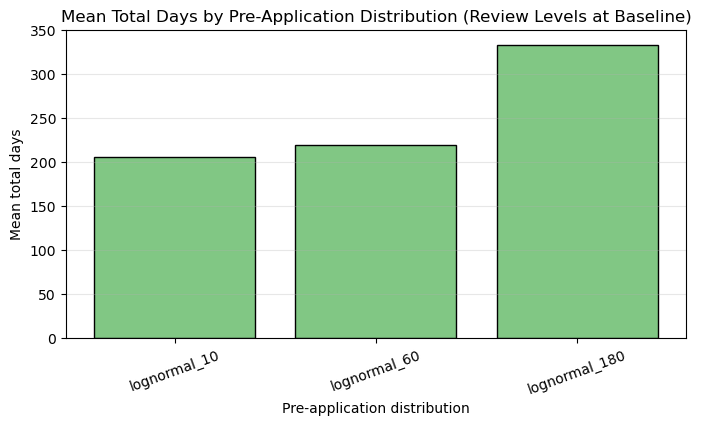

In [23]:
# Optional visualization: compare pre-application distributions at baseline review levels
plot_df = summary[
    (summary["planning_level"] == 1.0)
    & (summary["public_works_level"] == 1.0)
    & (summary["fire_level"] == 1.0)
    & (summary["special_zoning_level"] == 1.0)
    & (summary["agency_referral_level"] == 1.0)
].copy()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    plot_df["pre_application_distribution"],
    plot_df["mean_total_days"],
    color="#81C784",
    edgecolor="black",
)
ax.set_title("Mean Total Days by Pre-Application Distribution (Review Levels at Baseline)")
ax.set_xlabel("Pre-application distribution")
ax.set_ylabel("Mean total days")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=20)
plt.show()

In [24]:
# Export CSV outputs (every run + grouped summary) into Results folder
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
results_dir = Path("Results")
results_dir.mkdir(parents=True, exist_ok=True)

runs_csv = results_dir / f"sensitivity_runs_all_combinations_{timestamp}.csv"
summary_csv = results_dir / f"sensitivity_summary_all_combinations_{timestamp}.csv"

results_df.to_csv(runs_csv, index=False)
summary.to_csv(summary_csv, index=False)

print(f"Saved per-run results: {runs_csv}")
print(f"Saved grouped summary: {summary_csv}")
print(f"Per-run rows exported: {len(results_df)}")
print(f"Unique parameter combinations: {summary.shape[0]}")

summary.head()

Saved per-run results: Results/sensitivity_runs_all_combinations_20260427_135821.csv
Saved grouped summary: Results/sensitivity_summary_all_combinations_20260427_135821.csv
Per-run rows exported: 7290
Unique parameter combinations: 729


,pre_application_distribution,planning_level,public_works_level,fire_level,special_zoning_level,agency_referral_level,planning_staff_count,public_works_staff_count,fire_staff_count,n_runs_proxy,seed,completed_permits,mean_total_days,mean_application_to_ready_days,planning_to_ready_n,debris_blocking_wait_count,debris_blocking_wait_share,debris_blocking_wait_mean_days,debris_blocking_wait_median_days,debris_blocking_wait_max_days,median_total_days,std_total_days,min_total_days,max_total_days,mean_wait_days,mean_service_days,county_review_mean,applicant_mean,debris_mean,step_wait_mean__epa_debris,step_service_mean__epa_debris,step_wait_mean__usace_debris,step_service_mean__usace_debris,step_wait_mean__pre_application_activities,step_service_mean__pre_application_activities,step_wait_mean__applicant_revisions,step_service_mean__applicant_revisions,step_wait_mean__planning,step_service_mean__planning,step_wait_mean__agency_referral,step_service_mean__agency_referral,step_wait_mean__special_zoning,step_service_mean__special_zoning,step_wait_mean__public_works,step_service_mean__public_works,step_wait_mean__fire_review,step_service_mean__fire_review
0,lognormal_10,0.5,0.5,0.5,0.5,0.5,8.0,12.0,4.0,4.5,46.5,1200.0,146.674248,135.107707,1200.0,7.2,0.006000,10.470408,9.109534,24.637088,143.654034,48.829615,18.087275,366.817080,36.753020,129.735958,44.502633,107.117505,14.868840,3.154419,1.004798,8.210706,2.498917,0.0,11.566542,0.0,95.550964,25.284936,3.405716,0.0,3.755595,0.0,5.460618,0.000092,4.153720,0.102867,2.339089
1,lognormal_10,0.5,0.5,0.5,0.5,1.0,8.0,12.0,4.0,4.5,46.5,1200.0,148.181669,136.615128,1200.0,7.2,0.006000,10.470408,9.109534,24.637088,144.672087,50.262847,18.087275,402.784984,36.753020,133.491552,48.258228,107.117505,14.868840,3.154419,1.004798,8.210706,2.498917,0.0,11.566542,0.0,95.550964,25.284936,3.405716,0.0,7.511190,0.0,5.460618,0.000092,4.153720,0.102867,2.339089
2,lognormal_10,0.5,0.5,0.5,1.0,0.5,8.0,12.0,4.0,4.5,46.5,1200.0,152.574423,141.007881,1200.0,7.2,0.006000,10.281055,9.180807,23.333607,146.985870,56.843435,17.225356,524.916693,36.775559,135.722084,50.607900,107.030489,14.859254,3.136259,1.000141,8.224688,2.498167,0.0,11.566542,0.0,95.463947,25.329563,3.400935,0.0,3.828425,0.0,11.430104,0.000023,4.176196,0.085026,2.357628
3,lognormal_10,0.5,1.0,0.5,0.5,0.5,8.0,12.0,4.0,4.5,46.5,1200.0,153.115868,141.549326,1200.0,4.6,0.003833,9.168339,8.544985,17.441901,150.276903,49.529149,22.893101,384.198817,40.670280,134.653014,52.940582,107.528022,14.854691,3.148055,1.002716,8.205755,2.498167,0.0,11.566542,0.0,95.961480,25.423421,3.398423,0.0,3.857042,0.0,5.738859,3.810373,8.316619,0.082677,2.313167
4,lognormal_10,0.5,0.5,0.5,0.5,2.0,8.0,12.0,4.0,4.5,46.5,1200.0,153.370206,141.803664,1200.0,7.1,0.005917,10.601567,9.232151,24.637088,147.055269,58.546457,18.087275,611.205382,36.753020,141.002742,55.769418,107.117505,14.868840,3.154419,1.004798,8.210706,2.498917,0.0,11.566542,0.0,95.550964,25.284936,3.405716,0.0,15.022379,0.0,5.460618,0.000092,4.153720,0.102867,2.339089
